## imports & Noise Schedule

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ── Device ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# ── Noise Schedule ──────────────────────────────────────
T = 1000                                         # total timesteps
beta_start, beta_end = 1e-4, 0.02

betas    = torch.linspace(beta_start, beta_end, T).to(device)
alphas   = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)         # ᾱₜ

sqrt_alpha_bar     = torch.sqrt(alpha_bar)       # √ᾱₜ
sqrt_one_minus_ab  = torch.sqrt(1 - alpha_bar)   # √(1-ᾱₜ)
sqrt_recip_alpha   = torch.sqrt(1.0 / alphas)
sqrt_recip_ab_m1   = torch.sqrt(1.0 / alpha_bar - 1)

# Helper: extract value at timestep t for a batch
def extract(a, t, x_shape):
    b = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

Using: cuda


## Forward Process

In [ ]:
def q_sample(x0, t, noise=None):
    """
    Add noise to x0 at timestep t — the CLOSED FORM trick.
    xₜ = √ᾱₜ · x₀ + √(1-ᾱₜ) · ε
    """
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab_t   = extract(sqrt_alpha_bar,    t, x0.shape)
    sqrt_1mab_t = extract(sqrt_one_minus_ab, t, x0.shape)
    return sqrt_ab_t * x0 + sqrt_1mab_t * noise, noise

## U-Net Architecture

In [ ]:
# ── Sinusoidal Time Embedding ────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -torch.arange(half, device=device) * (np.log(10000) / (half - 1))
        )
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


# ── Residual Block ───────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


# ── Simple U-Net ─────────────────────────────────────────
class SimpleUNet(nn.Module):
    """
    U-Net for DDPM noise prediction.

    Encoder spatial sizes (img_size=32):
        x1 : [B, ch,    32, 32]  — after init_conv
        x2 : [B, ch*2,  16, 16]  — after pool + down1
        x3 : [B, ch*4,   8,  8]  — after pool + down2
        b  : [B, ch*4,   8,  8]  — bottleneck

    Decoder (skip connections paired by matching spatial size):
        up(b)  8→16, cat with x2 (16×16) → up1 → [B, ch*2, 16, 16]
        up(h) 16→32, cat with x1 (32×32) → up2 → [B, ch,   32, 32]
        out conv → [B, img_channels, 32, 32]
    """
    def __init__(self, img_channels=1, base_ch=64, t_dim=128):
        super().__init__()

        # Time embedding MLP
        self.t_mlp = nn.Sequential(
            SinusoidalPE(t_dim),
            nn.Linear(t_dim, t_dim * 4),
            nn.SiLU(),
            nn.Linear(t_dim * 4, t_dim),
        )

        ch = base_ch

        # ── Encoder ──────────────────────────────────────
        self.init_conv = nn.Conv2d(img_channels, ch, 3, padding=1)
        # pool is applied before each ResBlock to halve spatial dims
        self.pool  = nn.MaxPool2d(2)
        self.down1 = ResBlock(ch,   ch*2, t_dim)   # 32→16
        self.down2 = ResBlock(ch*2, ch*4, t_dim)   # 16→8

        # ── Bottleneck ───────────────────────────────────
        self.bot1 = ResBlock(ch*4, ch*4, t_dim)
        self.bot2 = ResBlock(ch*4, ch*4, t_dim)

        # ── Decoder ──────────────────────────────────────
        # up1: receives cat(up(b), x2) → ch*4 + ch*2 input channels
        self.up1 = ResBlock(ch*4 + ch*2, ch*2, t_dim)   # 8→16
        # up2: receives cat(up(h), x1) → ch*2 + ch   input channels
        self.up2 = ResBlock(ch*2 + ch,   ch,   t_dim)   # 16→32

        self.up = nn.Upsample(scale_factor=2, mode='nearest')

        # ── Output head ──────────────────────────────────
        self.out = nn.Sequential(
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv2d(ch, img_channels, 1),
        )

    def forward(self, x, t):
        t_emb = self.t_mlp(t)                          # [B, t_dim]

        # Encoder — store skips BEFORE pooling so they keep full resolution
        x1 = self.init_conv(x)                         # [B, ch,   32, 32]
        x2 = self.down1(self.pool(x1), t_emb)          # [B, ch*2, 16, 16]
        x3 = self.down2(self.pool(x2), t_emb)          # [B, ch*4,  8,  8]

        # Bottleneck
        b  = self.bot2(self.bot1(x3, t_emb), t_emb)   # [B, ch*4,  8,  8]

        # Decoder — each level pairs with the encoder skip of the SAME spatial size
        # up(b):  8→16, cat with x2 (16×16)
        h  = self.up1(torch.cat([self.up(b), x2], dim=1), t_emb)   # [B, ch*2, 16, 16]
        # up(h): 16→32, cat with x1 (32×32)
        h  = self.up2(torch.cat([self.up(h), x1], dim=1), t_emb)   # [B, ch,   32, 32]

        return self.out(h)                              # [B, img_channels, 32, 32]


## Training Loop

In [ ]:
# ── Dataset ──────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # scale to [-1, 1]
])

# Swap to CIFAR-10 by changing dataset + img_channels=3
dataset = datasets.MNIST(root='./data', train=True,
                         download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

# ── Model, optimizer ─────────────────────────────────────
model     = SimpleUNet(img_channels=1, base_ch=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Training ─────────────────────────────────────────────
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x0, _ in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x0 = x0.to(device)
        B  = x0.shape[0]

        # 1. Sample random timesteps
        t     = torch.randint(0, T, (B,), device=device).long()

        # 2. Add noise (forward process, one step)
        noise = torch.randn_like(x0)
        xt, _ = q_sample(x0, t, noise)

        # 3. Predict noise
        pred_noise = model(xt, t)

        # 4. Simple MSE loss (L_simple from paper)
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg = total_loss / len(loader)
    print(f"Epoch {epoch+1} | Loss: {avg:.4f}")

    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"ddpm_epoch{epoch+1}.pt")

Parameters: 4,585,281


Epoch 1/50: 100%|██████████| 469/469 [00:47<00:00,  9.82it/s]


Epoch 1 | Loss: 0.0570


Epoch 2/50: 100%|██████████| 469/469 [00:48<00:00,  9.76it/s]


Epoch 2 | Loss: 0.0260


...

Epoch 48 | Loss: 0.0154


Epoch 49/50: 100%|██████████| 469/469 [00:48<00:00,  9.72it/s]


Epoch 49 | Loss: 0.0154


Epoch 50/50: 100%|██████████| 469/469 [00:48<00:00,  9.72it/s]

Epoch 50 | Loss: 0.0151


Sampling: 100%|██████████| 1000/1000 [00:04<00:00, 201.34it/s]


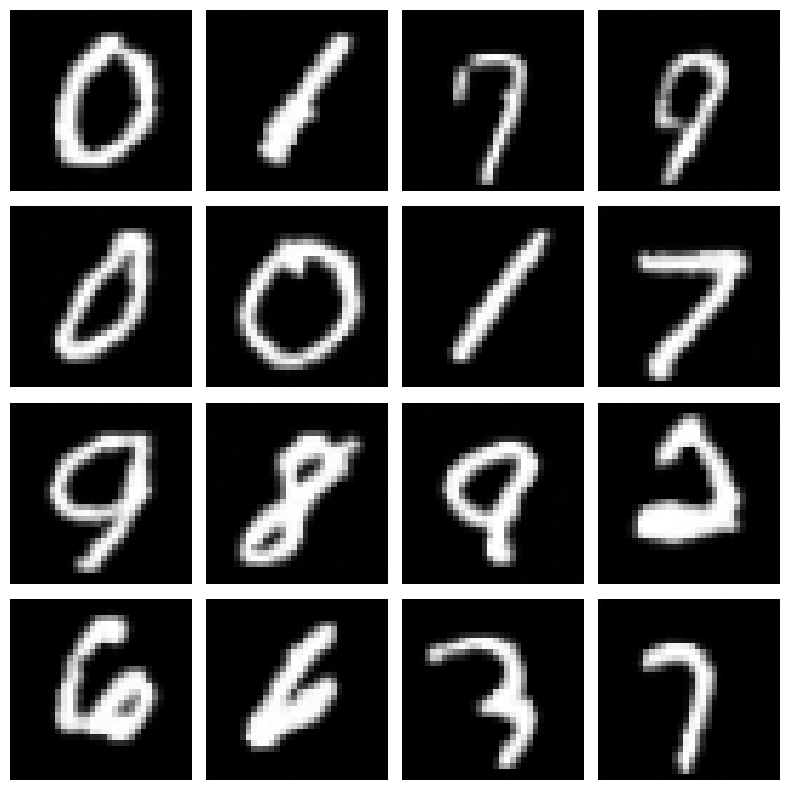

In [ ]:
@torch.no_grad()
def p_sample(model, x, t, t_idx):
    """One denoising step: predict x_{t-1} from x_t"""
    betas_t          = extract(betas,           t, x.shape)
    sqrt_1mab_t      = extract(sqrt_one_minus_ab, t, x.shape)
    sqrt_recip_a_t   = extract(sqrt_recip_alpha,  t, x.shape)

    # Equation 11 in DDPM paper
    pred_noise = model(x, t)
    model_mean = sqrt_recip_a_t * (x - betas_t / sqrt_1mab_t * pred_noise)

    if t_idx == 0:
        return model_mean
    else:
        posterior_var = betas_t
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_var) * noise

@torch.no_grad()
def sample(model, img_size=32, channels=1, n=16):
    model.eval()
    x = torch.randn(n, channels, img_size, img_size).to(device)

    for i in tqdm(reversed(range(T)), total=T, desc="Sampling"):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, i)

    # Rescale from [-1,1] to [0,1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x

# Generate and visualize
samples = sample(model, img_size=32, channels=1, n=16)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0].cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.savefig("generated_samples.png", dpi=150)
plt.show()